<center>
PAO25_25_02_Python_Datatype

July 08, 2026  

![Logo ITQ](img/LogoITQ.png)

**01 PAO26-26 Python 1, Funciones**  

![Logo Python](img/LogoPython.png)

</center>

**Docente:** Elvis Pachacama  

**Estudiante:** Dilan Salazar

**Repositorio:** [Machine Learning 2026](https://github.com/Dashmp/MachineLearning.git)

In [1]:
import pandas as pd
import numpy as np


In [2]:
pd.__version__

'2.3.3'

# 1 Operaciones en pandas
## Búsqueda

In [3]:
rand_matrix = np.random.randint(6,size=(2,3))
frame = pd.DataFrame(rand_matrix , columns=list('ABC'))
display(frame)

,A,B,C
0,1,4,1
1,1,3,2


In [4]:
# buscando columnas (DataFrame como dic, busca en claves)
'A' in frame


True

In [5]:
# buscando valores
display(frame.isin([3,2])) # --> mask de respuesta (valores que son 3 o 2)


,A,B,C
0,False,False,False
1,False,True,True


In [6]:
# Contar el número de ocurrencias
print(frame.isin([4]).values.sum())
display(frame.isin([4])) #devuelve una mask con valores true si el elemento es 4
print(frame.isin([4]).values)
type(frame.isin([4]).values) # pandas es una capa alrededor de numpy

1


,A,B,C
0,False,True,False
1,False,False,False


[[False  True False]
 [False False False]]


numpy.ndarray

In [7]:
# Cuántos valores son >= 2
mask = frame >= 2
print(mask.values.sum())
display(mask)

3


,A,B,C
0,False,True,False
1,False,True,True


## Ordenación

In [8]:
from random import shuffle
rand_matrix = np.random.randint(20,size=(5,4))
indices = list(range(5))
shuffle(indices) # mezcla indices
frame = pd.DataFrame(rand_matrix , columns=list('DACB'), index=indices)
display(frame)


,D,A,C,B
4,19,3,4,0
0,5,0,6,19
1,0,5,14,12
2,10,5,14,15
3,11,1,11,12


In [9]:
# ordenar por índice
display(frame.sort_index(ascending=False))
display(frame)

,D,A,C,B
4,19,3,4,0
3,11,1,11,12
2,10,5,14,15
1,0,5,14,12
0,5,0,6,19


,D,A,C,B
4,19,3,4,0
0,5,0,6,19
1,0,5,14,12
2,10,5,14,15
3,11,1,11,12


In [10]:
#ordenar por columna
display(frame.sort_index(axis=1, ascending=False))


,D,C,B,A
4,19,4,0,3
0,5,6,19,0
1,0,14,12,5
2,10,14,15,5
3,11,11,12,1


In [11]:
# ordenar filas por valor en columna
display(frame.sort_values(by='A', ascending=True))


,D,A,C,B
0,5,0,6,19
3,11,1,11,12
4,19,3,4,0
1,0,5,14,12
2,10,5,14,15


In [12]:
# ordenar columnas por valor en fila
display(frame.sort_values(by=1, axis=1, ascending=True))

,D,A,B,C
4,19,3,0,4
0,5,0,19,6
1,0,5,12,14
2,10,5,15,14
3,11,1,12,11


In [13]:
 # ordenar por valor en columna y guardar cambios
frame.sort_values(by='A', ascending=False, inplace=True)
display(frame)


,D,A,C,B
1,0,5,14,12
2,10,5,14,15
4,19,3,4,0
3,11,1,11,12
0,5,0,6,19


## Ranking
* Construir un ranking de valores


In [14]:
display(frame)


,D,A,C,B
1,0,5,14,12
2,10,5,14,15
4,19,3,4,0
3,11,1,11,12
0,5,0,6,19


In [15]:
display(frame.rank(method='max', axis=1))


,D,A,C,B
1,1.0,2.0,4.0,3.0
2,2.0,1.0,3.0,4.0
4,4.0,2.0,3.0,1.0
3,3.0,1.0,3.0,4.0
0,2.0,1.0,3.0,4.0


In [16]:
# Imprimir, uno a uno, los valores de la columna 'C' de mayor a menor
for x in frame.sort_values(by='C', ascending=False)['C'].values:
    print(x)

14
14
11
6
4


## 2 Operaciones
Operaciones matemáticas entre objetos

In [17]:
matrixA = np.random.randint(100,size=(4,4))
matrixB = np.random.randint(100,size=(4,4))
frameA = pd.DataFrame(matrixA)
frameB = pd.DataFrame(matrixB)
display(frameA)
display(frameB)

,0,1,2,3
0,35,43,25,32
1,44,73,96,60
2,61,80,41,31
3,48,7,80,14


,0,1,2,3
0,26,68,53,55
1,31,82,33,18
2,38,15,63,44
3,21,8,83,61


In [18]:
# a través de métodos u operadores
display(frameA + frameB == frameA.add(frameB))
display(frameA + frameB)


,0,1,2,3
0,True,True,True,True
1,True,True,True,True
2,True,True,True,True
3,True,True,True,True


,0,1,2,3
0,61,111,78,87
1,75,155,129,78
2,99,95,104,75
3,69,15,163,75


In [19]:
display(frameB - frameA == frameB.sub(frameA))
display(frameB - frameA)


,0,1,2,3
0,True,True,True,True
1,True,True,True,True
2,True,True,True,True
3,True,True,True,True


,0,1,2,3
0,-9,25,28,23
1,-13,9,-63,-42
2,-23,-65,22,13
3,-27,1,3,47


In [20]:
# si los frames no son iguales, valor por defecto NaN
frameC = pd.DataFrame(np.random.randint(100,size=(3,3)))
display(frameA)
display(frameC)
display(frameC + frameA)


,0,1,2,3
0,35,43,25,32
1,44,73,96,60
2,61,80,41,31
3,48,7,80,14


,0,1,2
0,68,87,93
1,87,58,30
2,43,87,28


,0,1,2,3
0,103.0,130.0,118.0,NaN
1,131.0,131.0,126.0,NaN
2,104.0,167.0,69.0,NaN
3,NaN,NaN,NaN,NaN


In [21]:
# se puede especificar el valor por defecto con el argumento fill_value
display(frameA.add(frameC, fill_value=0))


,0,1,2,3
0,103.0,130.0,118.0,32.0
1,131.0,131.0,126.0,60.0
2,104.0,167.0,69.0,31.0
3,48.0,7.0,80.0,14.0


Operadores aritméticos solo válidos en elementos aceptables


In [26]:
frameD = pd.DataFrame({0: ['a', 'b'], 1: ['d', 'f']})
display(frameD)

# 2. Convertir frameD a numérico PRIMERO (las letras pasarán a ser NaN)
frameD_numerico = frameD.apply(pd.to_numeric, errors='coerce')

# 3. Realizar la resta de manera segura
resultado = frameA - frameD_numerico
display(resultado)

,0,1
0,a,d
1,b,f


,0,1,2,3
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN


Operaciones entre Series y DataFrames


In [27]:
rand_matrix = np.random.randint(10, size=(3, 4))
df = pd.DataFrame(rand_matrix , columns=list('ABCD'))
display(df)
display(df.iloc[0])
display(type(df.iloc[0]))
# uso común, averiguar la diferencia entre una fila y el resto
display(df - df.iloc[0])
display(df.sub(df.iloc[0], axis=1))
# Por columnas cómo se restaría
display(df.sub(df['A'], axis=0))


,A,B,C,D
0,4,4,3,4
1,5,8,7,0
2,1,3,1,7


A    4
B    4
C    3
D    4
Name: 0, dtype: int32

pandas.core.series.Series

,A,B,C,D
0,0,0,0,0
1,1,4,4,-4
2,-3,-1,-2,3


,A,B,C,D
0,0,0,0,0
1,1,4,4,-4
2,-3,-1,-2,3


,A,B,C,D
0,0,0,-1,0
1,0,3,2,-5
2,0,2,0,6


pandas se basa en NumPy, np operadores binarios y unarios son aceptables


| Tipo | Operación | Descripción |
| :--- | :--- | :--- |
| **Unario** | `abs` | Valor absoluto de cada elemento |
| | `sqrt` | Raíz cuadrada de cada elemento |
| | `exp` | $e^x$, siendo $x$ cada elemento |
| | `log`, `log10`, `log2` | Logaritmos en distintas bases de cada elemento |
| | `sign` | Retorna el signo de cada elemento (-1 para negativo, 0 o 1 para positivo) |
| | `ceil` | Redondea cada elemento por arriba |
| | `floor` | Redondea cada elemento por abajo |
| | `isnan` | Retorna si cada elemento es NaN |
| | `cos`, `sin`, `tan` | Operaciones trigonométricas en cada elemento |
| | `arccos`, `arcsin`, `arctan` | Inversas de operaciones trigonométricas en cada elemento |
| **Binario** | `add` | Suma de dos arrays |
| | `substract` | Resta de dos arrays |
| | `multiply` | Multiplicación de dos arrays |
| | `divide` | División de dos arrays |
| | `maximum`, `minimum` | Retorna el valor máximo/mínimo de cada pareja de elementos |
| | `equal`, `not_equal` | Retorna la comparación (igual o no igual) de cada pareja de elementos |
| | `greater`, `greater_equal`, `less`, `less_equal` | Retorna la comparación (mayor, mayor o igual, menor, menor o igual respectivamente) de cada pareja de elementos |

In [28]:
rand_matrix = np.random.randint(10, size=(3, 4))
frame = pd.DataFrame(rand_matrix , columns=list('ABCD'))
display(frame)
print(frame.apply(lambda x : x.max() - x.min(), axis = 1)) # diferencia por␣columna

,A,B,C,D
0,4,2,1,2
1,8,9,4,4
2,3,1,5,9


0    3
1    5
2    8
dtype: int64


In [29]:
def max_min(x):
    return x.max() - x.min()
print(frame.apply(max_min, axis = 0)) # diferencia por columna

A    5
B    8
C    4
D    7
dtype: int64


In [30]:
# diferencia entre min y max por fila (no columna)
rand_matrix = np.random.randint(10, size=(3, 4))
frame = pd.DataFrame(rand_matrix , columns=list('ABCD'))
display(frame)
print(frame.apply(lambda x : x.max() - x.min(), axis = 1)) # diferencia por fila

,A,B,C,D
0,4,1,5,7
1,5,1,8,9
2,4,2,0,6


0    6
1    8
2    6
dtype: int64


| Operación | Descripción |
| :--- | :--- |
| `count` | Número de valores no NaN |
| `describe` | Conjunto de estadísticas sumarias |
| `min`, `max` | Valores mínimo y máximo |
| `argmin`, `argmax` | Índices posicionales del valor mínimo y máximo |
| `idxmin`, `idxmax` | Índices semánticos del valor mínimo y máximo |
| `sum` | Suma de los elementos |
| `mean` | Media de los elementos |
| `median` | Mediana de los elementos |
| `mad` | Desviación absoluta media del valor medio |
| `var` | Varianza de los elementos |
| `std` | Desviación estándar de los elementos |
| `cumsum` | Suma acumulada de los elementos |
| `diff` | Diferencia aritmética de los elementos |

In [31]:
diccionario = { "nombre" : ["Marisa","Laura","Manuel", "Carlos"], "edad" :[34,34,11, 30],
"puntos" : [98,12,98,np.nan], "genero": ["F", "F", "M", "M"] }
frame = pd.DataFrame(diccionario)
display(frame)
display(frame.describe()) # datos generales de elementos


,nombre,edad,puntos,genero
0,Marisa,34,98.0,F
1,Laura,34,12.0,F
2,Manuel,11,98.0,M
3,Carlos,30,NaN,M


,edad,puntos
count,4.000000,3.000000
mean,27.250000,69.333333
std,10.996211,49.652123
min,11.000000,12.000000
25%,25.250000,55.000000
50%,32.000000,98.000000
75%,34.000000,98.000000
max,34.000000,98.000000


In [32]:
# operadores básicos
print(frame.sum())
display(frame)
print(frame.sum(axis=1, numeric_only=True))

nombre    MarisaLauraManuelCarlos
edad                          109
puntos                      208.0
genero                       FFMM
dtype: object


,nombre,edad,puntos,genero
0,Marisa,34,98.0,F
1,Laura,34,12.0,F
2,Manuel,11,98.0,M
3,Carlos,30,NaN,M


0    132.0
1     46.0
2    109.0
3     30.0
dtype: float64


In [33]:
frame.mean(numeric_only=True)

edad      27.250000
puntos    69.333333
dtype: float64

In [34]:
frame.cumsum()

,nombre,edad,puntos,genero
0,Marisa,34,98.0,F
1,MarisaLaura,68,110.0,FF
2,MarisaLauraManuel,79,208.0,FFM
3,MarisaLauraManuelCarlos,109,NaN,FFMM


In [35]:
frame.count(axis=1)

0    4
1    4
2    4
3    3
dtype: int64

In [36]:
print(frame['edad'].std())

10.996211468804457


In [37]:
frame['edad'].idxmax()

0

In [38]:
frame['puntos'].idxmin()

1

In [39]:
# frame con las filas con los valores maximos de una columna
print(frame['puntos'].max())
display(frame[frame['puntos'] == frame['puntos'].max()])

98.0


,nombre,edad,puntos,genero
0,Marisa,34,98.0,F
2,Manuel,11,98.0,M


In [40]:
frame["ranking"] = frame["puntos"].rank(method='max')

In [41]:
display(frame)

,nombre,edad,puntos,genero,ranking
0,Marisa,34,98.0,F,3.0
1,Laura,34,12.0,F,1.0
2,Manuel,11,98.0,M,3.0
3,Carlos,30,NaN,M,NaN


# 3.1 Agregaciones


In [42]:
display(frame)
df = frame.groupby('genero').count()
display(df)


,nombre,edad,puntos,genero,ranking
0,Marisa,34,98.0,F,3.0
1,Laura,34,12.0,F,1.0
2,Manuel,11,98.0,M,3.0
3,Carlos,30,NaN,M,NaN


,nombre,edad,puntos,ranking
genero,,,,
F,2,2,2,2
M,2,2,1,1


In [43]:
# si es Nan descarta la fila
df = frame.groupby('puntos').count()
display(df)


,nombre,edad,genero,ranking
puntos,,,,
12.0,1,1,1,1
98.0,2,2,2,2


In [44]:
display(frame.groupby('genero').mean(numeric_only=True))


,edad,puntos,ranking
genero,,,
F,34.0,55.0,2.0
M,20.5,98.0,3.0


In [45]:
 display(frame.groupby('genero').max())


,nombre,edad,puntos,ranking
genero,,,,
F,Marisa,34,98.0,3.0
M,Manuel,30,98.0,3.0


In [46]:
# funciones de agregación de varias columnas para obtener distintos estadísticos
display(frame.groupby('genero')[['edad', 'puntos']].aggregate(['min', 'mean','max']))

edad           puntos            
        min  mean max    min  mean   max
genero                                  
F        34  34.0  34   12.0  55.0  98.0
M        11  20.5  30   98.0  98.0  98.0

In [48]:
# Filtrado de los datos en el que el conjunto no supera una media determinada
def media(x):
    return x["edad"].mean() > 30
display(frame)
frame.groupby('genero').filter(media)

,nombre,edad,puntos,genero,ranking
0,Marisa,34,98.0,F,3.0
1,Laura,34,12.0,F,1.0
2,Manuel,11,98.0,M,3.0
3,Carlos,30,NaN,M,NaN


,nombre,edad,puntos,genero,ranking
0,Marisa,34,98.0,F,3.0
1,Laura,34,12.0,F,1.0


## 3.2 Correlaciones
pandas incluye métodos para analizar correlaciones - Relación matemática entre dos variables
(-1 negativamente relacionadas, 1 positivamente relacionadas, 0 sin relación) - obj.corr(obj2) –
> medida de correlación entre los datos de ambos objetos - https://blogs.oracle.com/ai-anddatascience/post/introduction-to-correlation
3.2.1 Ejemplo Fuel efficiency
• https://archive.ics.uci.edu/ml/datasets/Auto+MPG

## 3.2.1 Ejemplo Fuel efficiency
* https://archive.ics.uci.edu/ml/datasets/Auto+MPG

In [51]:
import pandas as pd

# Corregimos la ruta añadiendo la barra '/' entre la carpeta y el archivo
path = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

mpg_data = pd.read_csv(
    path, 
    sep='\s+', 
    header=None,
    names=['mpg', 'cilindros', 'desplazamiento', 'potencia', 'peso', 'aceleracion', 'año', 'origen', 'nombre'],
    na_values='?', 
    engine='c'
)

# Validamos que se haya cargado correctamente mostrando las primeras filas
display(mpg_data.head())

,mpg,cilindros,desplazamiento,potencia,peso,aceleracion,año,origen,nombre
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [52]:
display(mpg_data.sample(5))

,mpg,cilindros,desplazamiento,potencia,peso,aceleracion,año,origen,nombre
221,17.5,8,305.0,145.0,3880.0,12.5,77,1,chevrolet caprice classic
158,16.0,8,318.0,150.0,4498.0,14.5,75,1,plymouth grand fury
194,22.5,6,232.0,90.0,3085.0,17.6,76,1,amc hornet
214,13.0,8,302.0,130.0,3870.0,15.0,76,1,ford f108
87,13.0,8,350.0,145.0,3988.0,13.0,73,1,chevrolet malibu


In [53]:
display(mpg_data.describe(include='all'))

,mpg,cilindros,desplazamiento,potencia,peso,aceleracion,año,origen,nombre
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,NaN


In [54]:
mpg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             398 non-null    float64
 1   cilindros       398 non-null    int64  
 2   desplazamiento  398 non-null    float64
 3   potencia        392 non-null    float64
 4   peso            398 non-null    float64
 5   aceleracion     398 non-null    float64
 6   año             398 non-null    int64  
 7   origen          398 non-null    int64  
 8   nombre          398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


## 3.2.2 Correlaciones entre valores

In [55]:
 mpg_data['mpg'].corr(mpg_data['peso']) # + mpg = - peso

np.float64(-0.8317409332443351)

In [56]:
mpg_data['peso'].corr(mpg_data['aceleracion']) # + peso = - aceleracion

np.float64(-0.4174573199403932)

## 3.2.3 Correlaciones entre todos los valores

In [57]:
mpg_data.corr(numeric_only=True)

,mpg,cilindros,desplazamiento,potencia,peso,aceleracion,año,origen
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267,0.563450
cilindros,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746,-0.562543
desplazamiento,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164,-0.609409
potencia,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
peso,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564,-0.581024
aceleracion,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137,0.205873
año,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000,0.180662
origen,0.563450,-0.562543,-0.609409,-0.455171,-0.581024,0.205873,0.180662,1.000000


In [58]:
#año y origen no parecen correlacionables
#eliminar columnas de la correlacion
corr_data = mpg_data.drop(['año','origen'],axis=1).corr(numeric_only=True)
display(corr_data)

,mpg,cilindros,desplazamiento,potencia,peso,aceleracion
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289
cilindros,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419
desplazamiento,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684
potencia,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196
peso,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457
aceleracion,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000


In [59]:
 # representación gráfica matplotlib
import matplotlib.pyplot as plt

In [60]:
# correlación más negativa
mpg_data.drop(['año','origen'],axis=1).corr(numeric_only=True).idxmin()

mpg                   peso
cilindros              mpg
desplazamiento         mpg
potencia               mpg
peso                   mpg
aceleracion       potencia
dtype: object

In [61]:
# correlación más positiva
mpg_data.drop(['año','origen'],axis=1).corr(numeric_only=True).idxmax() #consigo misma....


mpg                          mpg
cilindros              cilindros
desplazamiento    desplazamiento
potencia                potencia
peso                        peso
aceleracion          aceleracion
dtype: object

In [62]:
# tabla similar con las correlaciones más positivas (evitar parejas del mismo␣valor)
positive_corr = mpg_data.drop(['año','origen'],axis=1).corr(numeric_only=True)
np.fill_diagonal(positive_corr.values, 0)
display(positive_corr)
positive_corr.idxmax()


,mpg,cilindros,desplazamiento,potencia,peso,aceleracion
mpg,0.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289
cilindros,-0.775396,0.000000,0.950721,0.842983,0.896017,-0.505419
desplazamiento,-0.804203,0.950721,0.000000,0.897257,0.932824,-0.543684
potencia,-0.778427,0.842983,0.897257,0.000000,0.864538,-0.689196
peso,-0.831741,0.896017,0.932824,0.864538,0.000000,-0.417457
aceleracion,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,0.000000


mpg                  aceleracion
cilindros         desplazamiento
desplazamiento         cilindros
potencia          desplazamiento
peso              desplazamiento
aceleracion                  mpg
dtype: object

In [63]:
positive_corr.style.background_gradient(cmap=plt.get_cmap('RdYlGn'), axis=1,vmin=-1.0, vmax=1.0)

,mpg,cilindros,desplazamiento,potencia,peso,aceleracion
mpg,0.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289
cilindros,-0.775396,0.000000,0.950721,0.842983,0.896017,-0.505419
desplazamiento,-0.804203,0.950721,0.000000,0.897257,0.932824,-0.543684
potencia,-0.778427,0.842983,0.897257,0.000000,0.864538,-0.689196
peso,-0.831741,0.896017,0.932824,0.864538,0.000000,-0.417457
aceleracion,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,0.000000


## 3.3 Ejercicios
 Ejercicios para practicar Pandas: https://github.com/ajcr/100-pandaspuzzles/blob/master/100-pandas-puzzles.ipynb

# 3.4 Ejercicios Resueltos

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# =============================================================================
# PREPARACIÓN DEL ENTORNO Y CARGA DE DATOS
# =============================================================================

# Definimos la URL correcta del dataset auto-mpg en el repositorio de la UCI
path = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Cargamos el archivo usando espacios en blanco como separador y definiendo los nombres de las columnas
# Usamos na_values='?' para que convierta los signos de interrogación del dataset original en valores NaN
df = pd.read_csv(
    path,
    sep="\s+",
    header=None,
    names=[
        "mpg",
        "cilindros",
        "desplazamiento",
        "potencia",
        "peso",
        "aceleracion",
        "año",
        "origen",
        "nombre",
    ],
    na_values="?",
    engine="c",
)

# Configuramos Matplotlib para que los gráficos tengan un tamaño base estándar y limpio
plt.rcParams["figure.figsize"] = (9, 5)

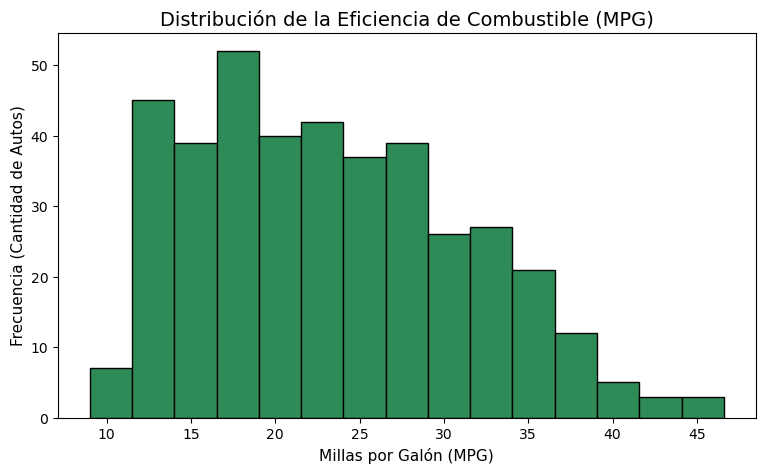

In [65]:
# =============================================================================
# EJERCICIO 1: HISTOGRAMA DE EFICIENCIA (MPG)
# =============================================================================

# Creamos una figura nueva para este gráfico independiente
plt.figure()

# Eliminamos filas donde 'mpg' sea nulo (NaN) para limpiar la serie de datos
mpg_limpio = df["mpg"].dropna()

# Dibujamos el histograma: 15 barras, color verde, bordes negros para separar las barras
plt.hist(mpg_limpio, bins=15, color="seagreen", edgecolor="black")

# Añadimos etiquetas informativas y títulos al gráfico
plt.title("Distribución de la Eficiencia de Combustible (MPG)", fontsize=14)
plt.xlabel("Millas por Galón (MPG)", fontsize=11)
plt.ylabel("Frecuencia (Cantidad de Autos)", fontsize=11)

# Mostramos el gráfico finalizado en pantalla
plt.show()

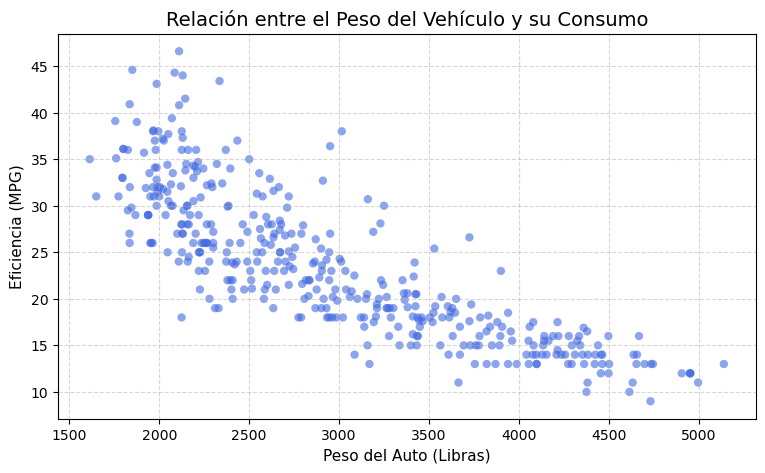

In [66]:
# =============================================================================
# EJERCICIO 2: RELACIÓN PESO VS. CONSUMO (GRÁFICO DE DISPERSIÓN)
# =============================================================================

plt.figure()

# Creamos el gráfico de dispersión (scatterplot)
# X: peso del auto, Y: millas por galón, alpha: transparencia 0.6 para ver solapamiento de puntos
plt.scatter(df["peso"], df["mpg"], color="royalblue", alpha=0.6, edgecolor="none")

# Añadimos cuadrícula de fondo para facilitar la lectura visual de las coordenadas
plt.grid(True, linestyle="--", alpha=0.5)

# Títulos y etiquetas de los ejes
plt.title("Relación entre el Peso del Vehículo y su Consumo", fontsize=14)
plt.xlabel("Peso del Auto (Libras)", fontsize=11)
plt.ylabel("Eficiencia (MPG)", fontsize=11)

plt.show()

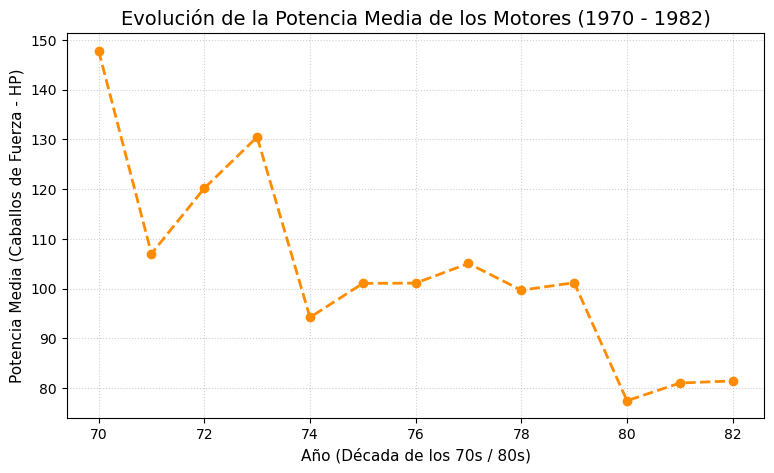

In [67]:
# =============================================================================
# EJERCICIO 3: EVOLUCIÓN DE LA POTENCIA A LO LARGO DE LOS AÑOS (LÍNEAS)
# =============================================================================

plt.figure()

# Agrupamos por la columna 'año' y extraemos la columna 'potencia'
# Calculamos la media (.mean()) ignorando automáticamente los valores NaN de la potencia
potencia_por_año = df.groupby("año")["potencia"].mean()

# Graficamos la serie resultante: eje X son los años (índice), eje Y la potencia media
# Usamos marcador circular 'o', línea discontinua '--' y color naranja oscuro
plt.plot(
    potencia_por_año.index,
    potencia_por_año.values,
    marker="o",
    linestyle="--",
    color="darkorange",
    linewidth=2,
)

# Activamos la cuadrícula de fondo
plt.grid(True, linestyle=":", alpha=0.6)

# Títulos y etiquetas
plt.title("Evolución de la Potencia Media de los Motores (1970 - 1982)", fontsize=14)
plt.xlabel("Año (Década de los 70s / 80s)", fontsize=11)
plt.ylabel("Potencia Media (Caballos de Fuerza - HP)", fontsize=11)

plt.show()

<Figure size 900x500 with 0 Axes>

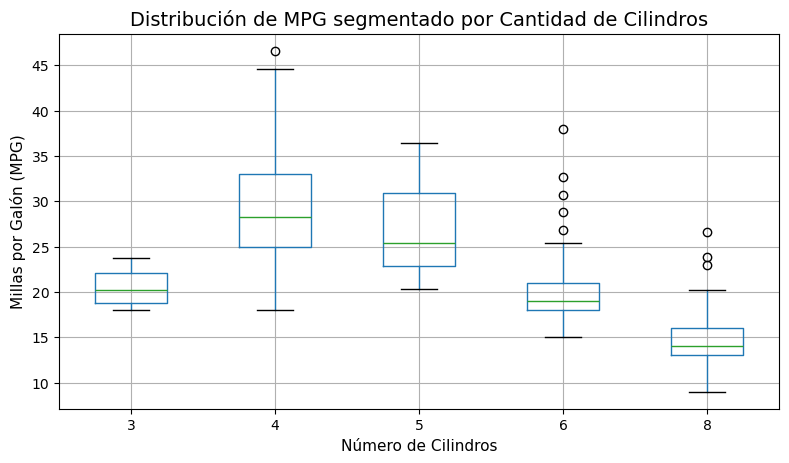

In [68]:
# =============================================================================
# EJERCICIO 4: DISTRIBUCIÓN DEL CONSUMO SEGÚN CILINDROS (DIAGRAMA DE CAJA)
# =============================================================================

plt.figure()

# Usamos la integración directa de Pandas con Matplotlib para generar el Boxplot
# column: la variable numérica a evaluar, by: la variable categórica para agrupar
df.boxplot(column="mpg", by="cilindros", grid=True)

# Personalizamos el título principal (limpiando el subtítulo automático que genera Pandas)
plt.title("Distribución de MPG segmentado por Cantidad de Cilindros", fontsize=14)
plt.suptitle("")  # Borra el título secundario por defecto de Pandas
plt.xlabel("Número de Cilindros", fontsize=11)
plt.ylabel("Millas por Galón (MPG)", fontsize=11)

plt.show()

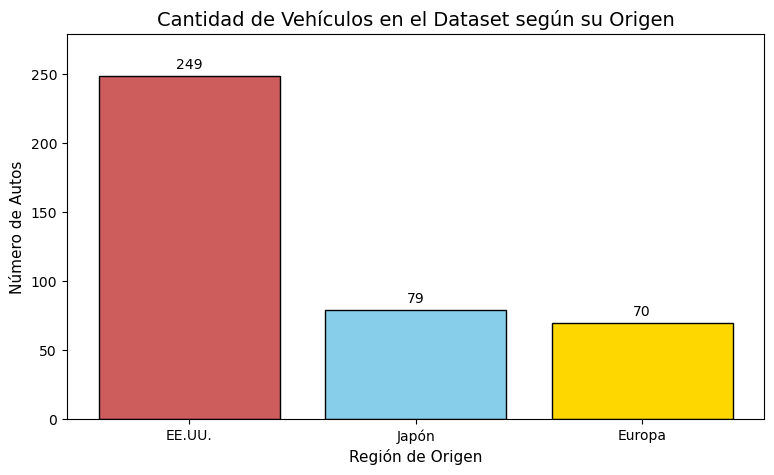

In [69]:
# =============================================================================
# EJERCICIO 5: COMPARATIVA DE ORIGEN (GRÁFICO DE BARRAS)
# =============================================================================

plt.figure()

# Mapeamos/reemplazamos los códigos numéricos de origen por sus nombres reales en texto
origen_mapeado = df["origen"].map({1: "EE.UU.", 2: "Europa", 3: "Japón"})

# Contamos cuántos registros existen de cada origen utilizando value_counts()
conteo_origen = origen_mapeado.value_counts()

# Dibujamos el gráfico de barras asignándole un color representativo a cada región
colores = ["indianred", "skyblue", "gold"]
barras = plt.bar(conteo_origen.index, conteo_origen.values, color=colores, edgecolor="black")

# Recorremos cada barra física para extraer su altura y renderizar el número exacto encima
for barra in barras:
    alto = barra.get_height()  # Obtenemos el valor numérico de la barra
    # Colocamos el texto: x = centro de la barra, y = altura + 3 unidades de margen
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        alto + 3,
        str(int(alto)),
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Títulos finales
plt.title("Cantidad de Vehículos en el Dataset según su Origen", fontsize=14)
plt.xlabel("Región de Origen", fontsize=11)
plt.ylabel("Número de Autos", fontsize=11)

# Ajustamos los límites del eje Y para asegurarnos de que las etiquetas numéricas no se corten arriba
plt.ylim(0, conteo_origen.max() + 30)

plt.show()